In [140]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")


In [141]:
import os

os.listdir(path)

['AEP_hourly.csv',
 'COMED_hourly.csv',
 'DAYTON_hourly.csv',
 'DEOK_hourly.csv',
 'DOM_hourly.csv',
 'DUQ_hourly.csv',
 'EKPC_hourly.csv',
 'est_hourly.paruqet',
 'FE_hourly.csv',
 'NI_hourly.csv',
 'PJME_hourly.csv',
 'PJMW_hourly.csv',
 'pjm_hourly_est.csv',
 'PJM_Load_hourly.csv']

In [142]:
import pandas as pd

df = pd.read_csv(os.path.join(path, "PJME_hourly.csv"))

print(df.shape)
print(df.head())

(145366, 2)
              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0


In [143]:
df["Datetime"]= pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime")
df = df.sort_index()

df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 145366 entries, 2002-01-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   PJME_MW  145366 non-null  float64
dtypes: float64(1)
memory usage: 2.2 MB


<Axes: xlabel='Datetime'>

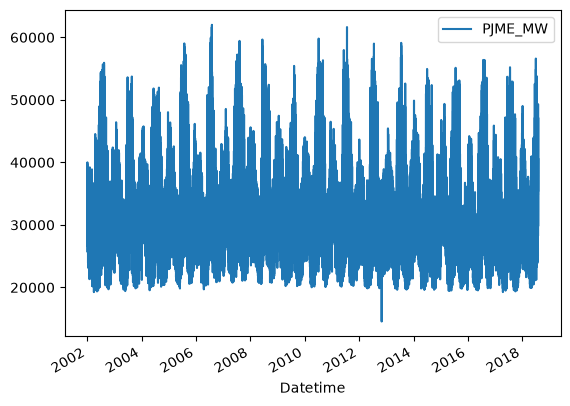

In [144]:
df.plot()

<Axes: xlabel='Datetime'>

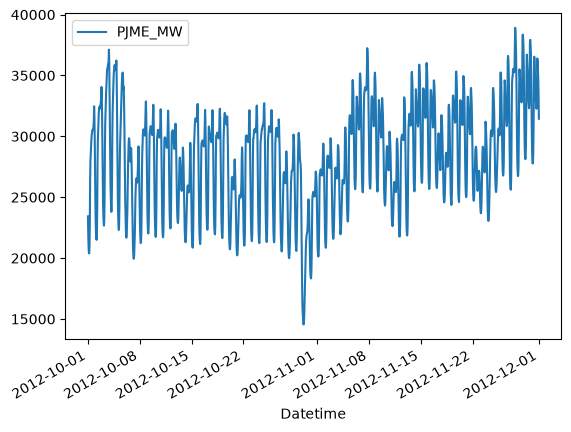

In [145]:
df["2012-10":"2012-11"].plot()

<Axes: xlabel='Datetime'>

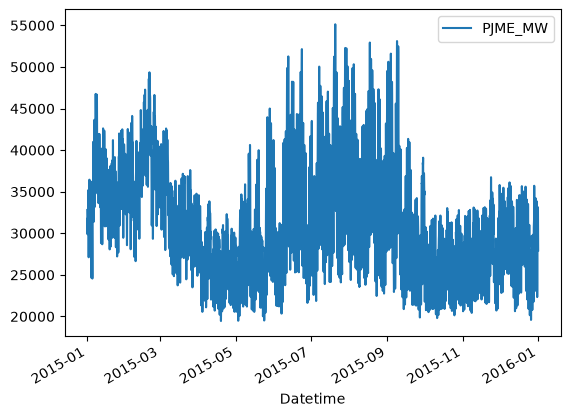

In [146]:
df.loc["2015"].plot()

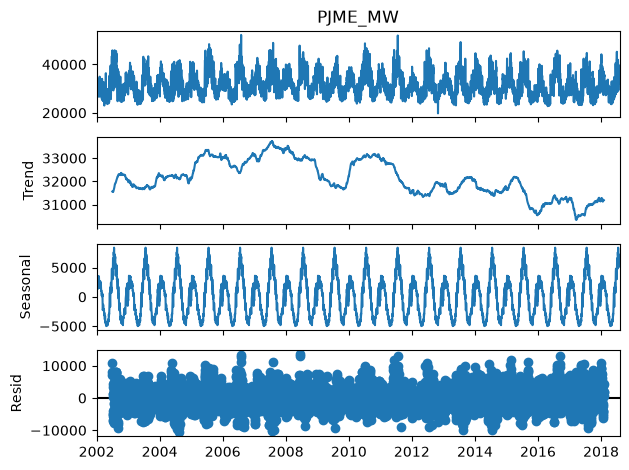

In [147]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily = df.resample("D").mean()

result = seasonal_decompose(daily["PJME_MW"], period=365)
result.plot();

### Additional Cols

In [148]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month
df["year"] = df.index.year

### Lag Features

In [149]:
df["lag_day"] = df["PJME_MW"].shift(24)
df["lag_week"] = df["PJME_MW"].shift(168)        

In [150]:
df.head(30)

,PJME_MW,hour,dayofweek,month,year,lag_day,lag_week
Datetime,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,2002,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,2002,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,2002,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,2002,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,2002,NaN,NaN
2002-01-01 06:00:00,28654.0,6,1,1,2002,NaN,NaN
2002-01-01 07:00:00,29308.0,7,1,1,2002,NaN,NaN
2002-01-01 08:00:00,29595.0,8,1,1,2002,NaN,NaN
2002-01-01 09:00:00,29943.0,9,1,1,2002,NaN,NaN


In [151]:
df["rolling_day"] = df["PJME_MW"].rolling(24).mean()
df["rolling_week"] = df["PJME_MW"].rolling(168).mean()

In [152]:
df = df.dropna()

In [153]:
df.columns

Index(['PJME_MW', 'hour', 'dayofweek', 'month', 'year', 'lag_day', 'lag_week',
       'rolling_day', 'rolling_week'],
      dtype='str')

### Train test split

In [154]:
train = df[df.index < "2017-01-01"]
test = df[df.index >= "2017-01-01"]

X_train = train.drop(columns=['PJME_MW'])
y_train = train['PJME_MW']
X_test = test.drop(columns=['PJME_MW'])
y_test = test['PJME_MW']

In [155]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

MAE: 1330.2539889176742
RMSE: 1785.5402785529072


<Axes: xlabel='Datetime'>

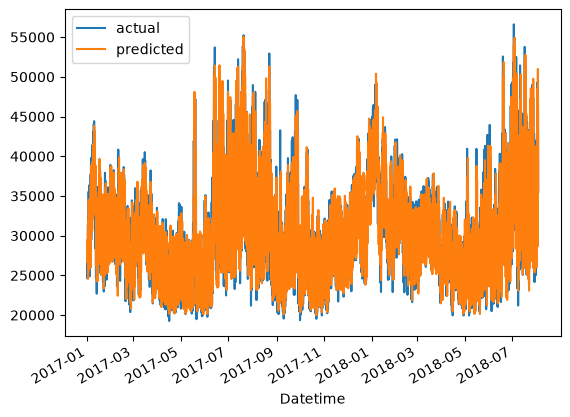

In [156]:
pd.DataFrame({"actual": y_test, "predicted": y_pred},
            index=y_test.index).plot()

In [157]:
pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

lag_day         0.766679
rolling_day     0.074207
lag_week        0.057283
hour            0.039106
dayofweek       0.030245
rolling_week    0.014083
month           0.011030
year            0.007367
dtype: float64